# A/H Detection Pipeline
Binary classification (With A-H vs No A-H) on BAH dataset frames using a causal transformer.

**Pipeline:**
1. Dataset statistics (split-frames + SegmentedFrames)
2. PyTorch Dataset / DataLoader
3. Causal Transformer model
4. Training (1 epoch)
5. Inference
6. Classification metrics

In [39]:
import os
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────
DATA_DIR         = Path('data')
SPLIT_FRAMES_DIR = DATA_DIR / 'split-frames'
FRAMES_DIR       = DATA_DIR / 'Frames'
SEG_FRAMES_DIR   = DATA_DIR / 'SegmentedFrames'

TRAIN_TXT = SPLIT_FRAMES_DIR / 'train.txt'
VAL_TXT   = SPLIT_FRAMES_DIR / 'val.txt'
TEST_TXT  = SPLIT_FRAMES_DIR / 'test.txt'

# ── Device ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

print(f'DATA_DIR         : {DATA_DIR.resolve()}')
print(f'FRAMES_DIR       : {FRAMES_DIR}  | exists: {FRAMES_DIR.exists()}')
print(f'SEG_FRAMES_DIR   : {SEG_FRAMES_DIR}  | exists: {SEG_FRAMES_DIR.exists()}')
print(f'TRAIN_TXT        : {TRAIN_TXT}  | exists: {TRAIN_TXT.exists()}')
print(f'VAL_TXT          : {VAL_TXT}  | exists: {VAL_TXT.exists()}')
print(f'TEST_TXT         : {TEST_TXT}  | exists: {TEST_TXT.exists()}')
print(f'Device           : {DEVICE}')

DATA_DIR         : /Users/ilyasar004/Documents/нир_моад/data
FRAMES_DIR       : data/Frames  | exists: True
SEG_FRAMES_DIR   : data/SegmentedFrames  | exists: True
TRAIN_TXT        : data/split-frames/train.txt  | exists: True
VAL_TXT          : data/split-frames/val.txt  | exists: True
TEST_TXT         : data/split-frames/test.txt  | exists: True
Device           : mps


## 1. Dataset Statistics

In [40]:
def load_split_file(path: Path) -> pd.DataFrame:
    """Read a split-frames .txt file.
    Each line: Videos/PATIENT/Visite_N/VIDEO.mp4/frame-N.jpg,LABEL
    """
    records = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.rsplit(',', 1)
            if len(parts) != 2:
                continue
            frame_rel, label_str = parts
            records.append({'frame_path': frame_rel, 'label': int(label_str)})
    return pd.DataFrame(records)


print('Loading split files...')
train_df = load_split_file(TRAIN_TXT)
val_df   = load_split_file(VAL_TXT)
test_df  = load_split_file(TEST_TXT)

CLASS_NAMES = {0: 'No A-H', 1: 'With A-H'}


def split_stats(df: pd.DataFrame, name: str) -> None:
    total  = len(df)
    counts = df['label'].value_counts().sort_index()
    print(f'\n── {name} ──')
    print(f'  Total frames : {total:,}')
    for cls_id, cnt in counts.items():
        print(f'  Class {cls_id} ({CLASS_NAMES[cls_id]:>8s}): {cnt:>8,}  ({cnt/total*100:.1f}%)')


split_stats(train_df, 'TRAIN')
split_stats(val_df,   'VAL')
split_stats(test_df,  'TEST')

# ── Segmented frames coverage ─────────────────────────────────────────────
print('\n── SegmentedFrames coverage ──')
if SEG_FRAMES_DIR.exists():
    seg_files = list(SEG_FRAMES_DIR.rglob('*.jpg'))
    print(f'  Total segmented files found: {len(seg_files):,}')
    sample_size = min(5000, len(train_df))
    sample_df   = train_df.sample(sample_size, random_state=SEED)
    covered = 0
    for fp in sample_df['frame_path']:
        seg_path = SEG_FRAMES_DIR / fp
        if seg_path.exists():
            covered += 1
    print(f'  Train sample ({sample_size:,} frames): {covered:,} have segmented version '
          f'({covered/sample_size*100:.1f}%)')
else:
    print(f'  SegmentedFrames directory not found: {SEG_FRAMES_DIR}')
    print('  Will use original Frames only.')

Loading split files...

── TRAIN ──
  Total frames : 501,970
  Class 0 (  No A-H):  425,468  (84.8%)
  Class 1 (With A-H):   76,502  (15.2%)

── VAL ──
  Total frames : 79,538
  Class 0 (  No A-H):   65,556  (82.4%)
  Class 1 (With A-H):   13,982  (17.6%)

── TEST ──
  Total frames : 335,110
  Class 0 (  No A-H):  269,361  (80.4%)
  Class 1 (With A-H):   65,749  (19.6%)

── SegmentedFrames coverage ──
  Total segmented files found: 107,760
  Train sample (5,000 frames): 1,104 have segmented version (22.1%)


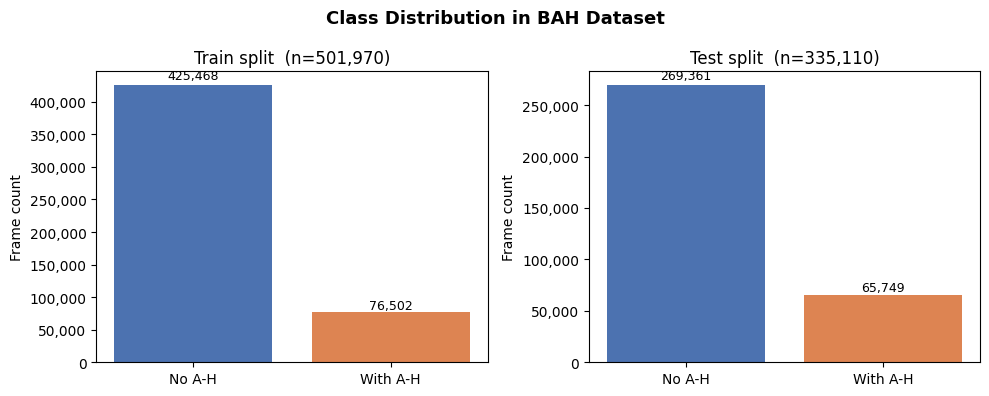

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (df, title) in zip(axes, [(train_df, 'Train'), (test_df, 'Test')]):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar([CLASS_NAMES[i] for i in counts.index], counts.values,
                  color=['#4C72B0', '#DD8452'])
    ax.set_title(f'{title} split  (n={len(df):,})', fontsize=12)
    ax.set_ylabel('Frame count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Class Distribution in BAH Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. PyTorch Dataset & DataLoader

In [42]:
# ── Hyper-parameters ─────────────────────────────────────────────────────
IMG_SIZE    = 224    # resize all frames to IMG_SIZE x IMG_SIZE
PATCH_SIZE  = 16     # transformer patch size
EMBED_DIM   = 256    # transformer embedding dimension
NUM_HEADS   = 8      # attention heads
NUM_LAYERS  = 4      # transformer encoder layers
MLP_RATIO   = 4.0    # MLP hidden dim = EMBED_DIM * MLP_RATIO
DROPOUT     = 0.1
NUM_CLASSES = 2

BATCH_SIZE  = 32
LR          = 3e-4
NUM_EPOCHS  = 1

# Subsample large splits to keep 1-epoch demo tractable (set None for full data)
MAX_TRAIN_SAMPLES = 20_000
MAX_VAL_SAMPLES   = 5_000
MAX_TEST_SAMPLES  = 5_000

print('Hyper-parameters:')
print(f'  IMG_SIZE={IMG_SIZE}, PATCH_SIZE={PATCH_SIZE}, EMBED_DIM={EMBED_DIM}')
print(f'  NUM_HEADS={NUM_HEADS}, NUM_LAYERS={NUM_LAYERS}')
print(f'  BATCH_SIZE={BATCH_SIZE}, LR={LR}, NUM_EPOCHS={NUM_EPOCHS}')
print(f'  MAX_TRAIN_SAMPLES={MAX_TRAIN_SAMPLES}, MAX_VAL_SAMPLES={MAX_VAL_SAMPLES}, MAX_TEST_SAMPLES={MAX_TEST_SAMPLES}')

Hyper-parameters:
  IMG_SIZE=224, PATCH_SIZE=16, EMBED_DIM=256
  NUM_HEADS=8, NUM_LAYERS=4
  BATCH_SIZE=32, LR=0.0003, NUM_EPOCHS=1
  MAX_TRAIN_SAMPLES=20000, MAX_VAL_SAMPLES=5000, MAX_TEST_SAMPLES=5000


In [43]:
class AHFrameDataset(Dataset):
    """Dataset for A/H frame-level binary classification.

    Tries to load the segmented version of each frame first;
    falls back to the original frame if segmentation is unavailable.
    When multiple segmented persons exist for one frame, the first one
    (sorted by person id) is used.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        frames_dir: Path,
        seg_frames_dir: Path,
        transform=None,
        use_segmented: bool = True,
        max_samples: int = None,
    ):
        if max_samples is not None and max_samples < len(df):
            df = (
                df.groupby('label', group_keys=False)
                  .apply(lambda g: g.sample(
                      min(len(g), max_samples // df['label'].nunique()),
                      random_state=SEED))
                  .reset_index(drop=True)
            )
        self.records       = df.reset_index(drop=True)
        self.frames_dir    = frames_dir
        self.seg_dir       = seg_frames_dir
        self.use_segmented = use_segmented
        self.transform     = transform

    def __len__(self) -> int:
        return len(self.records)

    def _resolve_path(self, frame_rel: str) -> Path:
        if self.use_segmented and self.seg_dir.exists():
            seg_path = self.seg_dir / frame_rel
            if seg_path.exists():
                return seg_path
        return self.frames_dir / frame_rel

    def __getitem__(self, idx: int):
        row      = self.records.iloc[idx]
        label    = int(row['label'])
        img_path = self._resolve_path(row['frame_path'])
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=0)
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Transforms ───────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Datasets ─────────────────────────────────────────────────────────────
train_dataset = AHFrameDataset(
    train_df, FRAMES_DIR, SEG_FRAMES_DIR,
    transform=train_transform,
    use_segmented=SEG_FRAMES_DIR.exists(),
    max_samples=MAX_TRAIN_SAMPLES,
)
val_dataset = AHFrameDataset(
    val_df, FRAMES_DIR, SEG_FRAMES_DIR,
    transform=test_transform,
    use_segmented=SEG_FRAMES_DIR.exists(),
    max_samples=MAX_VAL_SAMPLES,
)
test_dataset = AHFrameDataset(
    test_df, FRAMES_DIR, SEG_FRAMES_DIR,
    transform=test_transform,
    use_segmented=SEG_FRAMES_DIR.exists(),
    max_samples=MAX_TEST_SAMPLES,
)

print(f'Train dataset size : {len(train_dataset):,}')
print(f'Val   dataset size : {len(val_dataset):,}')
print(f'Test  dataset size : {len(test_dataset):,}')

# ── DataLoaders ───────────────────────────────────────────────────────────
# Use 0 workers on macOS/Windows to avoid multiprocessing spawn issues in notebooks
import platform
NUM_WORKERS = 0 if platform.system() in ('Darwin', 'Windows') else min(4, os.cpu_count() or 1)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE != 'cpu'),
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE != 'cpu'),
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE != 'cpu'),
)

print(f'Train batches : {len(train_loader):,}')
print(f'Val   batches : {len(val_loader):,}')
print(f'Test  batches : {len(test_loader):,}')

Train dataset size : 20,000
Val   dataset size : 5,000
Test  dataset size : 5,000
Train batches : 625
Val   batches : 157
Test  batches : 157


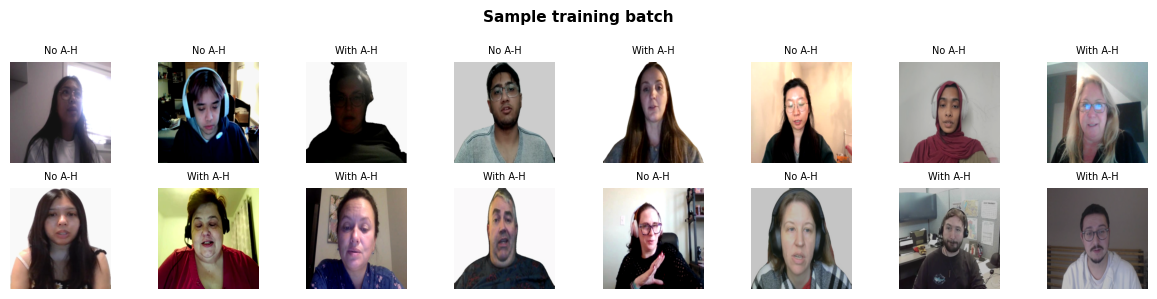

In [44]:
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

imgs, labels = next(iter(train_loader))
n_show = min(16, len(imgs))
cols   = 8
rows   = math.ceil(n_show / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
axes = np.array(axes).reshape(rows, cols)
for i, ax in enumerate(axes.flat):
    if i < n_show:
        img_np = denormalize(imgs[i]).permute(1, 2, 0).numpy()
        ax.imshow(img_np)
        ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample training batch', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Divided Space-Time Transformer (TimeSformer-style)

Architecture optimised for video / frame-sequence data:
1. **Patch Embedding** — split each frame into non-overlapping patches, project to `EMBED_DIM`
2. **[CLS] token** — prepended learnable classification token
3. **Spatial + Temporal Positional Embeddings** — separate learnable encodings for space and time
4. **Divided Space-Time Attention** — for each block, *temporal* attention is applied first (each spatial position attends across T frames), then *spatial* attention (each frame attends across N patches). Complexity O(T·N) vs O((T·N)²) for full attention.
5. **Classification Head** — MLP on the [CLS] token output → 2 logits

> In single-frame mode (T=1) temporal attention degenerates to a no-op and the model behaves like a standard ViT.

In [45]:
# ── Patch Embedding ──────────────────────────────────────────────────────
class PatchEmbedding(nn.Module):
    """Split a single frame into non-overlapping patches and project to D dims."""

    def __init__(self, img_size: int, patch_size: int, in_channels: int, embed_dim: int):
        super().__init__()
        assert img_size % patch_size == 0
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W) -> (B, N, D)
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x


# ── Divided Space-Time Attention block ───────────────────────────────────
class DividedSpaceTimeBlock(nn.Module):
    """TimeSformer-style divided attention block.

    For each token, temporal attention is applied first (across the T frames
    at the same spatial position), then spatial attention (across all N
    spatial patches within the same frame).  This factorisation is O(T*N)
    instead of O((T*N)^2) and is well-suited for video / frame-sequence data.

    When used on a single frame (T=1) the temporal attention degenerates to
    a no-op and the block behaves like a standard ViT block.
    """

    def __init__(self, embed_dim: int, num_heads: int, mlp_ratio: float, dropout: float):
        super().__init__()
        # Temporal attention
        self.norm_t  = nn.LayerNorm(embed_dim)
        self.attn_t  = nn.MultiheadAttention(embed_dim, num_heads,
                                              dropout=dropout, batch_first=True)
        # Spatial attention
        self.norm_s  = nn.LayerNorm(embed_dim)
        self.attn_s  = nn.MultiheadAttention(embed_dim, num_heads,
                                              dropout=dropout, batch_first=True)
        # MLP
        self.norm_mlp = nn.LayerNorm(embed_dim)
        mlp_hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor, T: int, N: int) -> torch.Tensor:
        """
        x : (B, 1 + T*N, D)  — [CLS] token followed by T*N patch tokens
        T : number of frames in the temporal window
        N : number of spatial patches per frame
        """
        B, L, D = x.shape
        cls, patches = x[:, :1], x[:, 1:]   # (B,1,D), (B,T*N,D)

        # ── Temporal attention ────────────────────────────────────────────
        # Reshape so each spatial position attends across T frames
        # (B*N, T, D)
        p = patches.reshape(B, T, N, D).permute(0, 2, 1, 3).reshape(B * N, T, D)
        p_n = self.norm_t(p)
        p_t, _ = self.attn_t(p_n, p_n, p_n)
        p = p + p_t
        # Restore to (B, T*N, D)
        patches = p.reshape(B, N, T, D).permute(0, 2, 1, 3).reshape(B, T * N, D)

        # ── Spatial attention ─────────────────────────────────────────────
        # Reshape so each frame attends across N patches; prepend CLS
        # (B*T, N+1, D)
        patches_t = patches.reshape(B, T, N, D)
        cls_exp   = cls.unsqueeze(1).expand(B, T, 1, D)
        sp_in     = torch.cat([cls_exp, patches_t], dim=2)   # (B, T, N+1, D)
        sp_in     = sp_in.reshape(B * T, N + 1, D)
        sp_n      = self.norm_s(sp_in)
        sp_out, _ = self.attn_s(sp_n, sp_n, sp_n)
        sp_in     = sp_in + sp_out
        sp_in     = sp_in.reshape(B, T, N + 1, D)
        # Average CLS contributions across frames, update patches
        cls     = sp_in[:, :, :1, :].mean(dim=1)             # (B, 1, D)
        patches = sp_in[:, :, 1:, :].reshape(B, T * N, D)

        # ── MLP ───────────────────────────────────────────────────────────
        out = torch.cat([cls, patches], dim=1)                # (B, 1+T*N, D)
        out = out + self.mlp(self.norm_mlp(out))
        return out


# ── Divided Space-Time Transformer ───────────────────────────────────────
class DividedSpaceTimeTransformer(nn.Module):
    """TimeSformer-inspired Vision Transformer with divided space-time attention.

    Designed for video / multi-frame inputs.  Each forward pass receives a
    batch of frames; the model treats them as a temporal sequence of length T
    (default T=1 for single-frame inference, set T>1 to process clips).

    Architecture:
      PatchEmbed  ->  [CLS] + spatial pos embed + temporal pos embed
      ->  L x DividedSpaceTimeBlock  ->  LayerNorm  ->  MLP head
    """

    def __init__(
        self,
        img_size: int    = 224,
        patch_size: int  = 16,
        in_channels: int = 3,
        num_classes: int = 2,
        embed_dim: int   = 256,
        num_heads: int   = 8,
        num_layers: int  = 4,
        mlp_ratio: float = 4.0,
        dropout: float   = 0.1,
        num_frames: int  = 1,   # T — temporal window size
    ):
        super().__init__()
        self.T = num_frames
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        N = self.patch_embed.num_patches  # spatial patches per frame

        self.cls_token    = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.spatial_pos  = nn.Parameter(torch.zeros(1, N + 1, embed_dim))
        self.temporal_pos = nn.Parameter(torch.zeros(1, num_frames, embed_dim))
        self.pos_drop     = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            DividedSpaceTimeBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.spatial_pos, std=0.02)
        nn.init.trunc_normal_(self.temporal_pos, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (B, C, H, W)  — single frame per sample (T=1 mode)
            OR
            (B*T, C, H, W) — pass num_frames=T and reshape before calling
        """
        B  = x.size(0) // self.T
        T  = self.T
        N  = self.patch_embed.num_patches

        # Patch embed: (B*T, N, D)
        patches = self.patch_embed(x)
        D = patches.size(-1)

        # Add spatial positional encoding (broadcast over T)
        # spatial_pos: (1, N+1, D) -> use only patch part (1, N, D)
        patches = patches + self.spatial_pos[:, 1:, :]

        # Add temporal positional encoding (broadcast over N)
        # temporal_pos: (1, T, D) -> (1, T, 1, D) -> (B, T, N, D)
        temp = self.temporal_pos[:, :T, :].unsqueeze(2)          # (1,T,1,D)
        patches = patches.reshape(B, T, N, D) + temp             # (B,T,N,D)
        patches = patches.reshape(B * T, N, D)

        # Prepend [CLS] token (one per sample in the batch)
        # We work at the B level (not B*T) inside the blocks
        patches = patches.reshape(B, T * N, D)
        cls     = self.cls_token.expand(B, -1, -1)               # (B,1,D)
        x_seq   = torch.cat([cls, patches], dim=1)               # (B,1+T*N,D)
        x_seq   = self.pos_drop(x_seq)

        for block in self.blocks:
            x_seq = block(x_seq, T=T, N=N)

        x_seq   = self.norm(x_seq)
        cls_out = x_seq[:, 0]                                    # (B, D)
        return self.head(cls_out)                                 # (B, num_classes)


# ── Instantiate & summarise ───────────────────────────────────────────────
model = DividedSpaceTimeTransformer(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE,
    num_classes=NUM_CLASSES, embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    mlp_ratio=MLP_RATIO, dropout=DROPOUT,
    num_frames=1,   # single-frame mode; increase for clip-level training
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: DividedSpaceTimeTransformer (TimeSformer-style)')
print(f'  Total params     : {total_params:,}')
print(f'  Trainable params : {trainable_params:,}')
print(f'  Spatial patches  : {model.patch_embed.num_patches}  per frame')
print(f'  Temporal frames  : {model.T}')

# Quick forward-pass sanity check
dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'  Output shape     : {tuple(out.shape)}  (batch=2, classes={NUM_CLASSES})')

Model: DividedSpaceTimeTransformer (TimeSformer-style)
  Total params     : 4,495,234
  Trainable params : 4,495,234
  Spatial patches  : 196  per frame
  Temporal frames  : 1
  Output shape     : (2, 2)  (batch=2, classes=2)


## 4. Training with Validation

In [46]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Cosine LR scheduler over all training steps across all epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=len(train_loader) * NUM_EPOCHS, eta_min=LR / 10
)


def train_one_epoch(model, loader, criterion, optimizer, scheduler, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0
    pbar = tqdm(loader, desc=f'Epoch {epoch} [train]', leave=True)
    for imgs, labels in pbar:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * imgs.size(0)
        preds    = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)

        pbar.set_postfix(loss=f'{loss.item():.4f}',
                         acc=f'{correct/total*100:.1f}%')

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device, desc='val'):
    """Run one pass over loader, return loss + detailed classification metrics."""
    model.eval()
    running_loss = 0.0
    all_preds  = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f'  [{desc}]', leave=False):
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    n = len(all_labels)
    metrics = {
        'loss'     : running_loss / n,
        'accuracy' : accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='binary', zero_division=0),
        'recall'   : recall_score(all_labels, all_preds, average='binary', zero_division=0),
        'f1'       : f1_score(all_labels, all_preds, average='binary', zero_division=0),
    }
    return metrics, all_labels, all_preds


def print_epoch_metrics(epoch, train_loss, train_acc, val_metrics):
    print(f'\n{"="*60}')
    print(f'  Epoch {epoch}/{NUM_EPOCHS}')
    print(f'{"="*60}')
    print(f'  Train  loss : {train_loss:.4f}   acc : {train_acc*100:.2f}%')
    print(f'  Val    loss : {val_metrics["loss"]:.4f}   acc : {val_metrics["accuracy"]*100:.2f}%')
    print(f'  Val    prec : {val_metrics["precision"]*100:.2f}%  '
          f'recall : {val_metrics["recall"]*100:.2f}%  '
          f'F1 : {val_metrics["f1"]*100:.2f}%')
    print(f'{"="*60}')


# ── Training loop ─────────────────────────────────────────────────────────
history = []
print(f'Starting training for {NUM_EPOCHS} epoch(s) on {DEVICE}...\n')

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler, DEVICE, epoch
    )
    val_metrics, _, _ = evaluate(model, val_loader, criterion, DEVICE, desc='val')
    print_epoch_metrics(epoch, train_loss, train_acc, val_metrics)
    history.append({
        'epoch'     : epoch,
        'train_loss': train_loss,
        'train_acc' : train_acc,
        **{f'val_{k}': v for k, v in val_metrics.items()},
    })

history_df = pd.DataFrame(history)
print('\nTraining complete.')
print(history_df.to_string(index=False))

Starting training for 1 epoch(s) on mps...



Epoch 1 [train]: 100%|██████████| 625/625 [01:55<00:00,  5.39it/s, acc=50.9%, loss=0.6951]



  Epoch 1/1
  Train  loss : 0.6929   acc : 50.93%
  Val    loss : 0.6957   acc : 48.20%
  Val    prec : 45.68%  recall : 19.04%  F1 : 26.88%

Training complete.
 epoch  train_loss  train_acc  val_loss  val_accuracy  val_precision  val_recall   val_f1
     1    0.692873     0.5093  0.695722         0.482       0.456814      0.1904 0.268775


## 5. Inference on Test Set

In [47]:
def run_inference(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []
    all_probs  = []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Inference', leave=True):
            imgs = imgs.to(device, non_blocking=True)
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1)
            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # prob of class 1
    return all_labels, all_preds, all_probs


y_true, y_pred, y_prob = run_inference(model, test_loader, DEVICE)
print(f'Inference complete. Evaluated {len(y_true):,} samples.')

Inference: 100%|██████████| 157/157 [00:12<00:00, 12.59it/s]

Inference complete. Evaluated 5,000 samples.


## 6. Classification Metrics

In [48]:
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='binary', zero_division=0)
rec  = recall_score(y_true, y_pred, average='binary', zero_division=0)
f1   = f1_score(y_true, y_pred, average='binary', zero_division=0)
cm   = confusion_matrix(y_true, y_pred)

print('=' * 45)
print('  Classification Metrics (Test Set)')
print('=' * 45)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print()
print(classification_report(
    y_true, y_pred,
    target_names=[CLASS_NAMES[0], CLASS_NAMES[1]],
    zero_division=0,
))

  Classification Metrics (Test Set)
  Accuracy  : 54.04%
  Precision : 69.20%
  Recall    : 14.56%
  F1-Score  : 24.06%

              precision    recall  f1-score   support

      No A-H       0.52      0.94      0.67      2500
    With A-H       0.69      0.15      0.24      2500

    accuracy                           0.54      5000
   macro avg       0.61      0.54      0.46      5000
weighted avg       0.61      0.54      0.46      5000



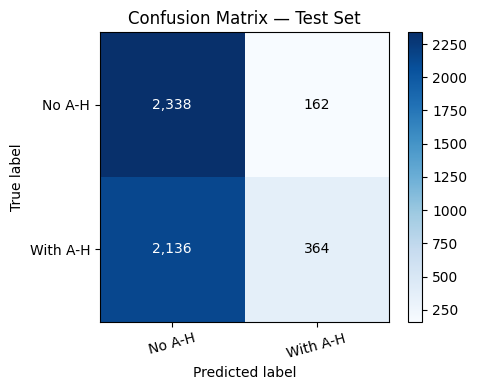

In [49]:
import itertools

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
tick_marks = range(NUM_CLASSES)
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels([CLASS_NAMES[i] for i in range(NUM_CLASSES)], rotation=15)
ax.set_yticklabels([CLASS_NAMES[i] for i in range(NUM_CLASSES)])

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, f'{cm[i, j]:,}',
            ha='center', va='center',
            color='white' if cm[i, j] > thresh else 'black')

ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

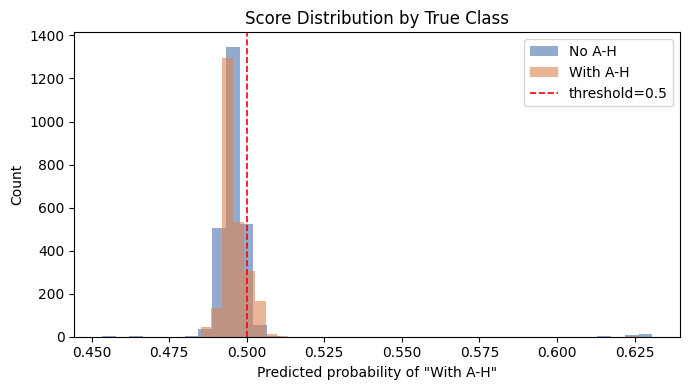

In [50]:
y_true_arr = np.array(y_true)
y_prob_arr = np.array(y_prob)

fig, ax = plt.subplots(figsize=(7, 4))
for cls_id, color, label in [(0, '#4C72B0', CLASS_NAMES[0]),
                              (1, '#DD8452', CLASS_NAMES[1])]:
    mask = y_true_arr == cls_id
    ax.hist(y_prob_arr[mask], bins=40, alpha=0.6, color=color, label=label)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='threshold=0.5')
ax.set_xlabel('Predicted probability of "With A-H"')
ax.set_ylabel('Count')
ax.set_title('Score Distribution by True Class')
ax.legend()
plt.tight_layout()
plt.show()